# Restaurant Data Preprocessing & Feature Engineering Pipeline

**Goal:** Transform raw restaurant data into a clean, feature-rich dataset with `business_score` and `customer_score` that Z.AI can use to generate actionable recommendations for restaurant owners.

**Pipeline flow:**
```
Raw CSV
  -> Quality Check & Cleaning
  -> Feature Engineering (ratios, composites, interactions)
  -> Business Score Module  -> raw_business [0-100]
  -> Customer Score Module  -> raw_customer [0-100]
  -> Standardize to z-scores
  -> Final table: scores + context columns + Revenue
  -> Export CSV for Z.AI
```

## 1. Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
print('Ready')

Ready


## 2. Load & Inspect

In [27]:
df_raw = pd.read_csv('restaurant_data.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: 'restaurant_data.csv'

## 3. Data Quality Check

In [ ]:
# Missing values
missing = df_raw.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() > 0 else '  None')

# Duplicates
n_dup = df_raw.duplicated().sum()
print(f'\nDuplicate rows: {n_dup}')

# Data types
print(f'\nData types:')
print(df_raw.dtypes)

Missing values:
  None

Duplicate rows: 0

Data types:
Name                       object
Location                   object
Cuisine                    object
Rating                    float64
Seating Capacity            int64
Average Meal Price        float64
Marketing Budget            int64
Social Media Followers      int64
Chef Experience Years       int64
Number of Reviews           int64
Avg Review Length         float64
Ambience Score            float64
Service Quality Score     float64
Parking Availability       object
Weekend Reservations        int64
Weekday Reservations        int64
Revenue                   float64
dtype: object


In [ ]:
# Value ranges for sanity checking
print('Categorical value counts:')
for col in ['Location', 'Cuisine', 'Parking Availability']:
    print(f'\n{col}:')
    print(df_raw[col].value_counts())

Categorical value counts:

Location:
Location
Downtown    2821
Suburban    2785
Rural       2762
Name: count, dtype: int64

Cuisine:
Cuisine
French      1433
American    1416
Italian     1413
Mexican     1393
Indian      1369
Japanese    1344
Name: count, dtype: int64

Parking Availability:
Parking Availability
Yes    4189
No     4179
Name: count, dtype: int64


In [ ]:
# Descriptive statistics
df_raw.describe()

,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Weekend Reservations,Weekday Reservations,Revenue
count,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000,8368.0000
mean,4.0083,60.2128,47.8967,3218.2549,36190.6218,10.0520,523.0104,174.7700,5.5213,5.5088,29.4918,29.2353,656070.5634
std,0.5815,17.3995,14.3368,1824.8961,18630.1533,5.5166,277.2151,71.9981,2.5754,2.5866,20.0254,20.0043,267413.7370
min,3.0000,30.0000,25.0000,604.0000,5277.0000,1.0000,50.0000,50.0117,1.0000,1.0000,0.0000,0.0000,184708.5200
25%,3.5000,45.0000,35.4900,1889.0000,22592.5000,5.0000,277.0000,113.3111,3.3000,3.2000,13.0000,13.0000,454651.3975
50%,4.0000,60.0000,45.5350,2846.5000,32518.5000,10.0000,528.0000,173.9101,5.5000,5.6000,27.0000,26.0000,604242.0850
75%,4.5000,75.0000,60.3000,4008.5000,44566.2500,15.0000,764.2500,237.4069,7.8000,7.8000,43.0000,43.0000,813094.2300
max,5.0000,90.0000,76.0000,9978.0000,103777.0000,19.0000,999.0000,299.9849,10.0000,10.0000,88.0000,88.0000,1531867.5500


## 4. Cleaning

- Drop the `Name` column (identifier, no predictive signal)
- Validate value ranges (Rating 0-5, Scores 0-10, Revenue > 0)
- Winsorize heavily skewed columns at 1st-99th percentile to reduce outlier distortion

In [ ]:
df = df_raw.copy()

# Drop identifier
df.drop(columns=['Name'], inplace=True)

# Validate ranges
before = len(df)
df = df[
    (df['Rating'] >= 0) & (df['Rating'] <= 5) &
    (df['Ambience Score'] >= 0) & (df['Ambience Score'] <= 10) &
    (df['Service Quality Score'] >= 0) & (df['Service Quality Score'] <= 10) &
    (df['Revenue'] > 0)
]
print(f'Rows removed by validation: {before - len(df)} | Remaining: {len(df)}')

# Winsorize skewed columns at 1st-99th percentile
skewed_cols = ['Marketing Budget', 'Social Media Followers', 'Revenue']
for col in skewed_cols:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f'Winsorized {col:30s} [{lo:,.0f}, {hi:,.0f}]')

# Separate target before feature engineering
target = df['Revenue'].copy()

print(f'\nCleaned shape: {df.shape}')

Rows removed by validation: 0 | Remaining: 8368
Winsorized Marketing Budget               [774, 8,699]
Winsorized Social Media Followers         [9,331, 92,040]
Winsorized Revenue                        [239,801, 1,365,233]

Cleaned shape: (8368, 16)


## 5. Encode Categorical Variables

- `Parking Availability`: Binary encode (Yes=1, No=0)
- `Location`: One-hot encode (3 categories: Downtown, Rural, Suburban)
- `Cuisine`: One-hot encode (6 categories: American, French, Indian, Italian, Japanese, Mexican)

We keep the original categorical columns for Z.AI context and create encoded versions for score computation.

In [ ]:
# Save original categoricals for Z.AI context
cuisine_raw = df['Cuisine'].copy()
location_raw = df['Location'].copy()
parking_raw = df['Parking Availability'].copy()

# Binary encode Parking
df['Parking_Available'] = (df['Parking Availability'] == 'Yes').astype(int)

# One-hot encode Location and Cuisine
df = pd.get_dummies(df, columns=['Location', 'Cuisine'], drop_first=False, dtype=int)

# Drop the original Parking text column (binary version replaces it)
df.drop(columns=['Parking Availability'], inplace=True)

encoded_cols = [c for c in df.columns if c.startswith(('Location_', 'Cuisine_', 'Parking_'))]
print(f'Encoded columns: {encoded_cols}')
print(f'Shape after encoding: {df.shape}')

Encoded columns: ['Parking_Available', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Cuisine_American', 'Cuisine_French', 'Cuisine_Indian', 'Cuisine_Italian', 'Cuisine_Japanese', 'Cuisine_Mexican']
Shape after encoding: (8368, 23)


## 6. Feature Engineering

### 6a. Reservation & Capacity Features

In [ ]:
# Total weekly reservations
df['total_reservations'] = df['Weekend Reservations'] + df['Weekday Reservations']

# Seat utilization: demand vs capacity (values > 1 = demand exceeds single-sitting capacity)
df['seat_utilization'] = df['total_reservations'] / df['Seating Capacity']

# Weekend reservation share: captures leisure/destination appeal
df['weekend_reservation_share'] = df['Weekend Reservations'] / (df['total_reservations'] + 1)

# Weekday-to-weekend ratio: higher = more business-lunch oriented
df['weekday_weekend_ratio'] = df['Weekday Reservations'] / (df['Weekend Reservations'] + 1)

print('Reservation features created:')
print(df[['total_reservations', 'seat_utilization', 'weekend_reservation_share', 'weekday_weekend_ratio']].describe())

Reservation features created:
       total_reservations  seat_utilization  weekend_reservation_share  \
count           8368.0000         8368.0000                  8368.0000   
mean              58.7271            0.9744                     0.4890   
std               30.7439            0.4090                     0.2380   
min                0.0000            0.0000                     0.0000   
25%               36.0000            0.6800                     0.3265   
50%               54.0000            0.9730                     0.4913   
75%               78.0000            1.2667                     0.6522   
max              169.0000            1.9412                     0.9877   

       weekday_weekend_ratio  
count              8368.0000  
mean                  2.2457  
std                   5.1848  
min                   0.0000  
25%                   0.4762  
50%                   0.9680  
75%                   1.8571  
max                  81.0000  


### 6b. Financial & Marketing Features

In [ ]:
# Marketing efficiency: revenue generated per dollar of marketing spend
df['marketing_efficiency'] = df['Revenue'] / df['Marketing Budget']
df['marketing_efficiency'] = df['marketing_efficiency'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Revenue per seat: operational revenue density
df['revenue_per_seat'] = df['Revenue'] / df['Seating Capacity']

# Marketing spend per seat: how much marketing investment per capacity unit
df['marketing_per_seat'] = df['Marketing Budget'] / df['Seating Capacity']

# Revenue per reservation: spend-per-visit proxy
df['revenue_per_reservation'] = df['Revenue'] / df['total_reservations'].replace(0, np.nan)
df['revenue_per_reservation'] = df['revenue_per_reservation'].fillna(0)

# Price-to-rating ratio: value perception (higher = expensive for the quality)
df['price_rating_ratio'] = df['Average Meal Price'] / df['Rating']

print('Financial features created:')
print(df[['marketing_efficiency', 'revenue_per_seat', 'marketing_per_seat', 'revenue_per_reservation', 'price_rating_ratio']].describe())

Financial features created:
       marketing_efficiency  revenue_per_seat  marketing_per_seat  \
count             8368.0000         8368.0000           8368.0000   
mean               260.7768        10948.7416             54.0449   
std                170.0567         3146.1632             25.6693   
min                 49.7925         5651.9017             11.0524   
25%                143.3393         8211.5135             33.2977   
50%                211.4896        10406.1092             50.3670   
75%                324.4389        13696.7119             70.9320   
max               1463.7874        17824.3203            161.4333   

       revenue_per_reservation  price_rating_ratio  
count                8368.0000           8368.0000  
mean                16019.3505             12.2129  
std                 24901.9789              4.1252  
min                     0.0000              5.1020  
25%                  7966.0140              8.8616  
50%                 11116.5686  

### 6c. Customer Engagement Features

In [ ]:
# Reviews per follower: engagement rate (how many followers actually leave reviews)
df['reviews_per_follower'] = df['Number of Reviews'] / df['Social Media Followers']

# Social media reach per marketing dollar
df['followers_per_marketing_dollar'] = df['Social Media Followers'] / df['Marketing Budget']
df['followers_per_marketing_dollar'] = df['followers_per_marketing_dollar'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Review engagement depth: longer reviews per review count = more invested customers
df['review_depth'] = df['Avg Review Length'] * df['Number of Reviews']

print('Engagement features created:')
print(df[['reviews_per_follower', 'followers_per_marketing_dollar', 'review_depth']].describe())

Engagement features created:
       reviews_per_follower  followers_per_marketing_dollar  review_depth
count             8368.0000                       8368.0000     8368.0000
mean                 0.0187                         11.6841    91523.1014
std                  0.0150                          1.7050    64649.5794
min                  0.0006                          8.4984     2780.8245
25%                  0.0078                         10.5019    39560.4436
50%                  0.0150                         11.2797    75902.2725
75%                  0.0252                         12.3729   132076.3897
max                  0.1053                         20.5126   299313.0502


### 6d. Composite Quality Scores

In [ ]:
# Experience score: normalized average of Rating, Service Quality, Ambience
# Each component scaled to [0, 1] before averaging to prevent scale bias
df['experience_score'] = (
    (df['Rating'] / 5) +
    (df['Service Quality Score'] / 10) +
    (df['Ambience Score'] / 10)
) / 3

# Chef-to-capacity ratio: experienced chef managing more seats = more operational pressure
df['chef_capacity_ratio'] = df['Chef Experience Years'] / df['Seating Capacity']

# Quality-price index: experience relative to meal price (higher = better value)
df['quality_price_index'] = df['experience_score'] / (df['Average Meal Price'] / df['Average Meal Price'].max())

print('Composite features created:')
print(df[['experience_score', 'chef_capacity_ratio', 'quality_price_index']].describe())

Composite features created:
       experience_score  chef_capacity_ratio  quality_price_index
count         8368.0000            8368.0000            8368.0000
mean             0.6349               0.1833               1.1035
std              0.1279               0.1216               0.4057
min              0.2800               0.0111               0.3170
25%              0.5467               0.0882               0.7895
50%              0.6367               0.1667               1.0315
75%              0.7267               0.2508               1.3701
max              0.9767               0.6333               2.8182


### 6e. Feature Correlation with Revenue

Check which engineered features are most predictive of Revenue.

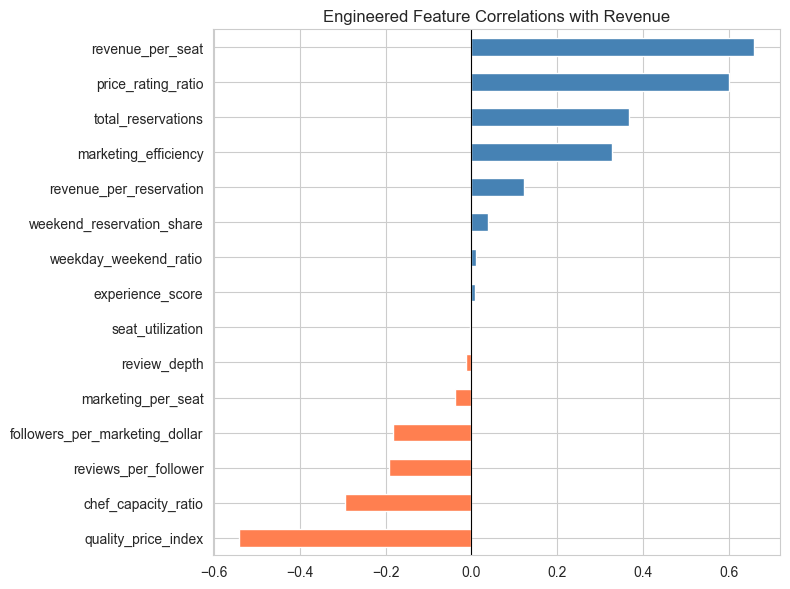

quality_price_index              -0.5428
chef_capacity_ratio              -0.2955
reviews_per_follower             -0.1915
followers_per_marketing_dollar   -0.1830
marketing_per_seat               -0.0395
review_depth                     -0.0123
seat_utilization                 -0.0025
experience_score                  0.0087
weekday_weekend_ratio             0.0098
weekend_reservation_share         0.0377
revenue_per_reservation           0.1215
marketing_efficiency              0.3275
total_reservations                0.3687
price_rating_ratio                0.6011
revenue_per_seat                  0.6598
Name: Revenue, dtype: float64


In [ ]:
# Correlations of engineered features with Revenue
engineered = [
    'total_reservations', 'seat_utilization', 'weekend_reservation_share', 'weekday_weekend_ratio',
    'marketing_efficiency', 'revenue_per_seat', 'marketing_per_seat', 'revenue_per_reservation',
    'price_rating_ratio', 'reviews_per_follower', 'followers_per_marketing_dollar',
    'review_depth', 'experience_score', 'chef_capacity_ratio', 'quality_price_index'
]

corr_with_rev = df[engineered + ['Revenue']].corr()['Revenue'].drop('Revenue').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_rev.plot(kind='barh', ax=ax, color=['coral' if v < 0 else 'steelblue' for v in corr_with_rev])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Engineered Feature Correlations with Revenue')
plt.tight_layout()
plt.show()

print(corr_with_rev.round(4))

## 7. Business Score Module

Captures **operational strength and market presence**. Each component is transformed to [0, 100] via MinMax, then averaged.

| Component | Source | Transform | Rationale |
|---|---|---|---|
| Ambience | `Ambience Score` | MinMax [0,100] | Direct environment quality |
| Service | `Service Quality Score` | MinMax [0,100] | Direct staff quality |
| Chef expertise | `Chef Experience Years` | MinMax [0,100] | Drives food quality & reputation |
| Marketing investment | `Marketing Budget` | log1p -> MinMax [0,100] | Log reduces skew from high-budget outliers |
| Seat fill rate | Total Reservations / Seating Capacity | MinMax [0,100] | Operational efficiency |

In [ ]:
mm = MinMaxScaler(feature_range=(0, 100))

def minmax_col(s):
    return mm.fit_transform(s.values.reshape(-1, 1)).flatten()

b_comp = pd.DataFrame({
    'ambience':      minmax_col(df['Ambience Score']),
    'service':       minmax_col(df['Service Quality Score']),
    'chef_exp':      minmax_col(df['Chef Experience Years']),
    'log_marketing': minmax_col(np.log1p(df['Marketing Budget'])),
    'utilization':   minmax_col(df['seat_utilization']),
})

raw_business = b_comp.mean(axis=1)

print(f'raw_business  mean={raw_business.mean():.2f}  std={raw_business.std():.2f}  skew={raw_business.skew():.3f}')
print(raw_business.describe().round(2))

raw_business  mean=50.66  std=11.93  skew=-0.031
count   8368.0000
mean      50.6600
std       11.9300
min       11.0800
25%       42.2800
50%       50.7000
75%       59.0900
max       89.0800
dtype: float64


Business component correlations with Revenue:
  ambience            : 0.0032
  service             : 0.0054
  chef_exp            : 0.0269
  log_marketing       : 0.3361
  utilization         : -0.0025


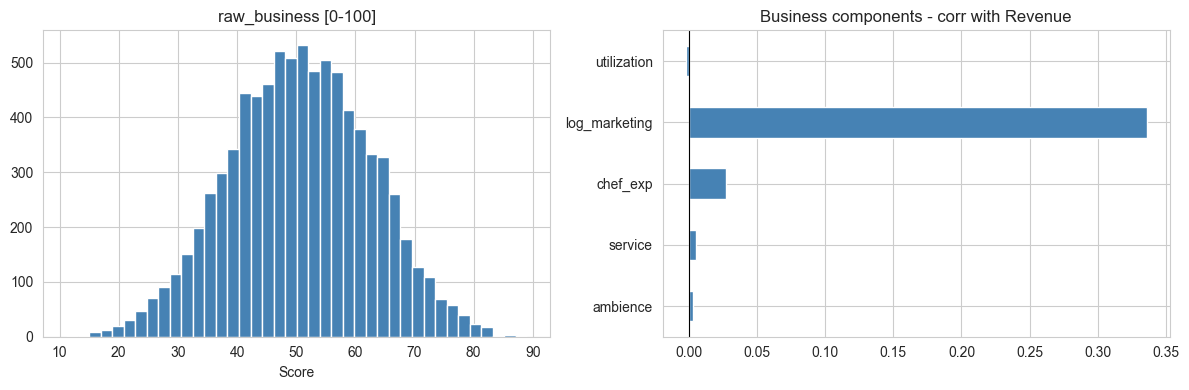

In [ ]:
# Business score component correlations with Revenue
print('Business component correlations with Revenue:')
for col in b_comp.columns:
    print(f'  {col:20s}: {b_comp[col].corr(target):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_business, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('raw_business [0-100]')
axes[0].set_xlabel('Score')

b_comp.corrwith(target).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Business components - corr with Revenue')
plt.tight_layout()
plt.show()

## 8. Customer Score Module

Captures **customer satisfaction, engagement, and demand**.

| Component | Source | Transform | Rationale |
|---|---|---|---|
| Satisfaction | `Rating` | MinMax [0,100] | Core quality signal |
| Brand reach | `Social Media Followers` | log1p -> MinMax [0,100] | Log compresses follower range |
| Review volume | `Number of Reviews` | log1p -> MinMax [0,100] | Log handles long-tail counts |
| Engagement depth | `Avg Review Length` | MinMax [0,100] | Longer reviews = more invested customers |
| Weekend demand | Weekend / (Total + 1) | MinMax [0,100] | Captures leisure/destination appeal |

In [ ]:
c_comp = pd.DataFrame({
    'rating':        minmax_col(df['Rating']),
    'log_followers': minmax_col(np.log1p(df['Social Media Followers'])),
    'log_reviews':   minmax_col(np.log1p(df['Number of Reviews'])),
    'review_length': minmax_col(df['Avg Review Length']),
    'weekend_share': minmax_col(df['weekend_reservation_share']),
})

raw_customer = c_comp.mean(axis=1)

print(f'raw_customer  mean={raw_customer.mean():.2f}  std={raw_customer.std():.2f}  skew={raw_customer.skew():.3f}')
print(raw_customer.describe().round(2))

raw_customer  mean=54.99  std=12.12  skew=-0.072
count   8368.0000
mean      54.9900
std       12.1200
min       10.3800
25%       46.7500
50%       55.2200
75%       63.4800
max       92.2600
dtype: float64


Customer component correlations with Revenue:
  rating              : 0.0095
  log_followers       : 0.3252
  log_reviews         : -0.0125
  review_length       : -0.0115
  weekend_share       : 0.0377


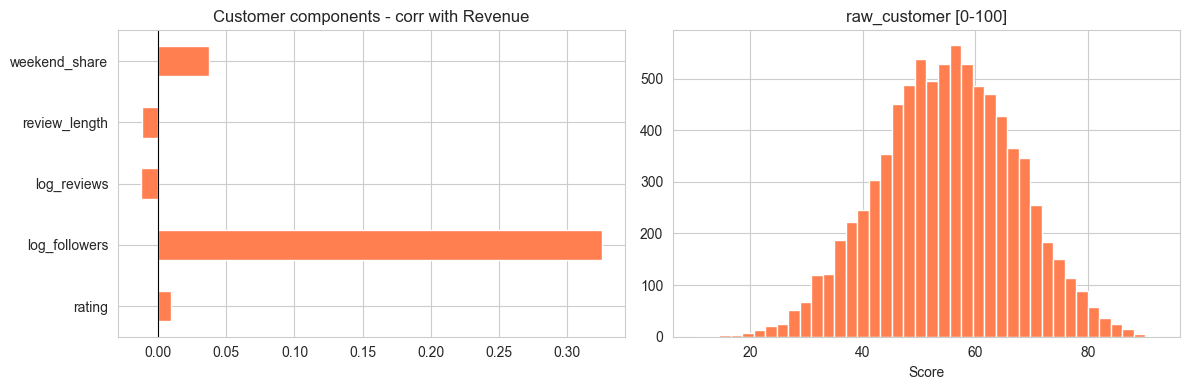

In [ ]:
# Customer score component correlations with Revenue
print('Customer component correlations with Revenue:')
for col in c_comp.columns:
    print(f'  {col:20s}: {c_comp[col].corr(target):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[1].hist(raw_customer, bins=40, color='coral', edgecolor='white')
axes[1].set_title('raw_customer [0-100]')
axes[1].set_xlabel('Score')

c_comp.corrwith(target).plot(kind='barh', ax=axes[0], color='coral')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Customer components - corr with Revenue')
plt.tight_layout()
plt.show()

## 9. Standardize Scores to Z-Scores

Scores are standardized to mean=0, std=1 so Z.AI interprets them as z-scores:

| z-score | Interpretation |
|---|---|
| > +1.5 | Significantly above average |
| +0.5 to +1.5 | Above average |
| -0.5 to +0.5 | Average |
| -1.5 to -0.5 | Below average |
| < -1.5 | Significantly below average |

In [ ]:
sc = StandardScaler()
scores_std = sc.fit_transform(np.column_stack([raw_business, raw_customer]))

business_score = scores_std[:, 0]
customer_score = scores_std[:, 1]

print('Standardized scores:')
print(f'  business_score  mean={business_score.mean():.4f}  std={business_score.std():.4f}  range=[{business_score.min():.2f}, {business_score.max():.2f}]')
print(f'  customer_score  mean={customer_score.mean():.4f}  std={customer_score.std():.4f}  range=[{customer_score.min():.2f}, {customer_score.max():.2f}]')
print(f'\nInter-score correlation: {np.corrcoef(business_score, customer_score)[0,1]:.4f}')

Standardized scores:
  business_score  mean=0.0000  std=1.0000  range=[-3.32, 3.22]
  customer_score  mean=-0.0000  std=1.0000  range=[-3.68, 3.08]

Inter-score correlation: 0.2090


## 10. Assemble Final Dataset

**Structure:**
- `business_score`, `customer_score` — standardized z-scores for Z.AI to evaluate performance
- All engineered features — for Z.AI to explain *why* and generate specific recommendations
- Original context columns (Cuisine, Location, etc.) — Z.AI uses these to ground recommendations
- `Revenue` — target

In [ ]:
# Build final dataset
final = pd.DataFrame({
    'business_score': business_score,
    'customer_score': customer_score,
})

# Add back original categorical context for Z.AI
final['Cuisine'] = cuisine_raw.values
final['Location'] = location_raw.values
final['Parking_Available'] = parking_raw.map({'Yes': 1, 'No': 0}).values

# Add all numeric columns from cleaned df (including engineered features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove Revenue from features (it's the target)
numeric_cols.remove('Revenue')

for col in numeric_cols:
    if col not in final.columns:  # avoid duplicating Parking_Available
        final[col] = df[col].values

# Add target
final['Revenue'] = target.values

print(f'Final table shape: {final.shape}')
print(f'\nColumns:')
for c in final.columns:
    print(f'  {c}')

Final table shape: (8368, 42)

Columns:
  business_score
  customer_score
  Cuisine
  Location
  Parking_Available
  Rating
  Seating Capacity
  Average Meal Price
  Marketing Budget
  Social Media Followers
  Chef Experience Years
  Number of Reviews
  Avg Review Length
  Ambience Score
  Service Quality Score
  Weekend Reservations
  Weekday Reservations
  Location_Downtown
  Location_Rural
  Location_Suburban
  Cuisine_American
  Cuisine_French
  Cuisine_Indian
  Cuisine_Italian
  Cuisine_Japanese
  Cuisine_Mexican
  total_reservations
  seat_utilization
  weekend_reservation_share
  weekday_weekend_ratio
  marketing_efficiency
  revenue_per_seat
  marketing_per_seat
  revenue_per_reservation
  price_rating_ratio
  reviews_per_follower
  followers_per_marketing_dollar
  review_depth
  experience_score
  chef_capacity_ratio
  quality_price_index
  Revenue


In [ ]:
# Validation
assert final.isnull().sum().sum() == 0, 'NaN values detected!'
assert abs(final['business_score'].mean()) < 0.01, 'business_score not zero-mean!'
assert abs(final['customer_score'].mean()) < 0.01, 'customer_score not zero-mean!'
assert abs(final['business_score'].std() - 1.0) < 0.01, 'business_score std != 1!'
assert abs(final['customer_score'].std() - 1.0) < 0.01, 'customer_score std != 1!'
assert 'Revenue' in final.columns, 'Target missing!'
assert 'Cuisine' in final.columns, 'Context columns missing!'
print('All validation checks passed')
final.head()

All validation checks passed


,business_score,customer_score,Cuisine,Location,Parking_Available,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,...,marketing_per_seat,revenue_per_reservation,price_rating_ratio,reviews_per_follower,followers_per_marketing_dollar,review_depth,experience_score,chef_capacity_ratio,quality_price_index,Revenue
0,-0.8378,-0.3863,Japanese,Rural,1,4.0000,38,73.9800,2224.0000,23406.0000,...,58.5263,37585.0306,18.4950,0.0079,10.5243,29956.1076,0.5433,0.3421,0.5582,638945.5200
1,-1.0294,0.1371,Mexican,Downtown,1,3.2000,76,28.1100,4416.0000,42741.0000,...,58.1053,9077.9228,8.7844,0.0125,9.6787,79288.9294,0.4133,0.1053,1.1175,490207.8300
2,0.8275,0.5459,Italian,Rural,0,4.7000,48,48.2900,2796.0000,37285.0000,...,58.2500,13204.1127,10.2745,0.0229,13.3351,48492.3586,0.7133,0.3750,1.1227,541368.6200
3,-1.1782,-1.1768,Italian,Rural,1,4.4000,34,51.5500,1167.0000,15214.0000,...,34.3235,15559.8769,11.7159,0.0054,13.0368,16845.5278,0.5400,0.3824,0.7961,404556.8000
4,-0.1900,0.5567,Japanese,Downtown,0,4.9000,88,75.9800,3639.0000,40171.0000,...,41.3523,21670.3654,15.5061,0.0019,11.0390,18851.1636,0.6833,0.1023,0.6835,1365233.0231


## 11. Score Visualization

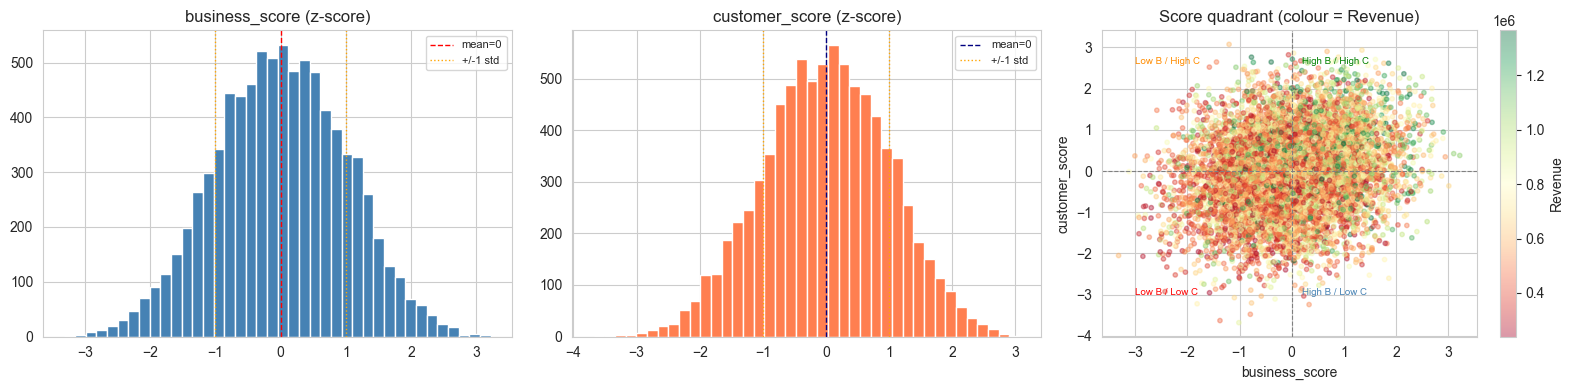

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Business score histogram
axes[0].hist(final['business_score'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='mean=0')
axes[0].axvline(1, color='orange', linestyle=':', linewidth=1)
axes[0].axvline(-1, color='orange', linestyle=':', linewidth=1, label='+/-1 std')
axes[0].set_title('business_score (z-score)')
axes[0].legend(fontsize=8)

# Customer score histogram
axes[1].hist(final['customer_score'], bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='navy', linestyle='--', linewidth=1, label='mean=0')
axes[1].axvline(1, color='orange', linestyle=':', linewidth=1)
axes[1].axvline(-1, color='orange', linestyle=':', linewidth=1, label='+/-1 std')
axes[1].set_title('customer_score (z-score)')
axes[1].legend(fontsize=8)

# Quadrant map
sc_plot = axes[2].scatter(
    final['business_score'], final['customer_score'],
    c=final['Revenue'], cmap='RdYlGn', alpha=0.4, s=10
)
axes[2].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('business_score')
axes[2].set_ylabel('customer_score')
axes[2].set_title('Score quadrant (colour = Revenue)')
plt.colorbar(sc_plot, ax=axes[2], label='Revenue')
axes[2].text( 0.2,  2.6, 'High B / High C', fontsize=7, color='green')
axes[2].text(-3.0,  2.6, 'Low B / High C',  fontsize=7, color='darkorange')
axes[2].text( 0.2, -3.0, 'High B / Low C',  fontsize=7, color='steelblue')
axes[2].text(-3.0, -3.0, 'Low B / Low C',   fontsize=7, color='red')

plt.tight_layout()
plt.show()

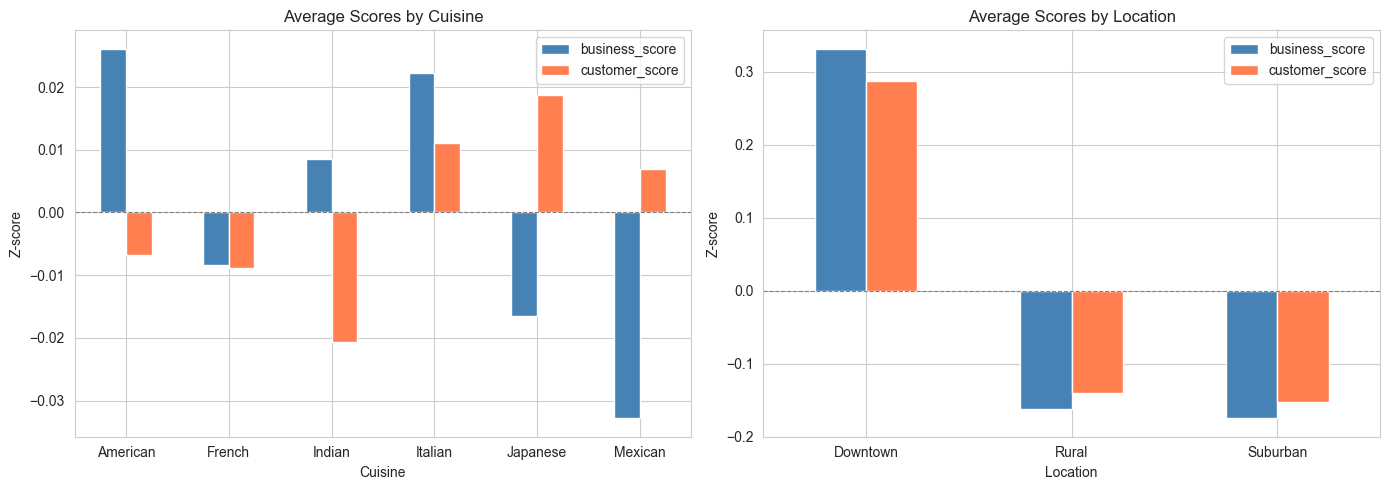

In [ ]:
# Score breakdown by Cuisine and Location
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

final.groupby('Cuisine')[['business_score', 'customer_score']].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral']
)
axes[0].set_title('Average Scores by Cuisine')
axes[0].set_ylabel('Z-score')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=0)

final.groupby('Location')[['business_score', 'customer_score']].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral']
)
axes[1].set_title('Average Scores by Location')
axes[1].set_ylabel('Z-score')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 12. Outlier Flagging

Flag high-revenue outliers using IQR on the **original** Revenue values. These are kept in the dataset but flagged so Z.AI can account for them.

In [ ]:
Q1 = final['Revenue'].quantile(0.25)
Q3 = final['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

final['is_high_revenue_outlier'] = (final['Revenue'] > upper).astype(int)
print(f'High-revenue outliers: {final["is_high_revenue_outlier"].sum()} / {len(final)}')
print(f'IQR upper bound: ${upper:,.2f}')

High-revenue outliers: 102 / 8368
IQR upper bound: $1,350,758.48


## 13. Export

In [ ]:
final.to_csv('restaurant_final.csv', index=False)

print(f'Exported: restaurant_final.csv')
print(f'Shape: {final.shape}')
print(f'\nZ.AI payload structure per restaurant:')
print(f'  business_score (z-score) - operational strength')
print(f'  customer_score (z-score) - customer satisfaction & engagement')
print(f'  + Context columns (Cuisine, Location, Rating, etc.) for WHY')
print(f'  + Engineered features (seat_utilization, marketing_efficiency, etc.)')
print(f'  + Revenue (target)')
print(f'\nSample row:')
print(final.iloc[0].to_dict())

Exported: restaurant_final.csv
Shape: (8368, 43)

Z.AI payload structure per restaurant:
  business_score (z-score) - operational strength
  customer_score (z-score) - customer satisfaction & engagement
  + Context columns (Cuisine, Location, Rating, etc.) for WHY
  + Engineered features (seat_utilization, marketing_efficiency, etc.)
  + Revenue (target)

Sample row:
{'business_score': -0.8378275410393375, 'customer_score': -0.3863028624549639, 'Cuisine': 'Japanese', 'Location': 'Rural', 'Parking_Available': 1, 'Rating': 4.0, 'Seating Capacity': 38, 'Average Meal Price': 73.98, 'Marketing Budget': 2224.0, 'Social Media Followers': 23406.0, 'Chef Experience Years': 13, 'Number of Reviews': 185, 'Avg Review Length': 161.92490574327928, 'Ambience Score': 1.3, 'Service Quality Score': 7.0, 'Weekend Reservations': 13, 'Weekday Reservations': 4, 'Location_Downtown': 0, 'Location_Rural': 1, 'Location_Suburban': 0, 'Cuisine_American': 0, 'Cuisine_French': 0, 'Cuisine_Indian': 0, 'Cuisine_Itali